<a href="https://colab.research.google.com/github/ipal8181/UnwindingStochasticOrderFlow/blob/main/Copy_of_internal_liquidity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FX Market Making with Internal Liquidity

As the foreign exchange market continues to evolve, many institutions now offer passive access to their internal liquidity pools. Market makers act as principal and have the opportunity to fill those orders as part of their risk management, or they may choose to adjust pricing to their external OTC franchise to facilitate the matching flow.  It is, a priori, unclear how strategies to manage internal liquidity should depend, if at all, on market conditions, the market maker's appetite for risk, and the trading strategies deployed by clients. The market maker's actions in the presence of these passive orders are relevant not only for their own objectives, but also for clients providing liquidity who desire rapid execution.

This notebook is based on our paper, 'FX Market Making with Internal Liquidity' by Alexander Barzykin, Robert Boyce, and Eyal Neuman. The paper has been published in Risk cutting edge:

https://www.risk.net/cutting-edge/7963389/fx-market-making-with-internal-liquidity

and can also be found on SSRN:

https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5859484

If you use this code, please cite our paper:

```bibtex
@article{barzykin2026fx,
  title={FX Market Making with Internal Liquidity},
  author={Barzykin, Alexander and Boyce, Robert and Neuman, Eyal},
  journal={Risk},
  year={2026}
}
```

Tune parameters with the ``ModelParams`` class, and play around for yourself.

### Model description

We consider a finite trading period $[0, T]$. There is a streamed pricing ladder, so the dealer continuously posts bid and ask prices
$$
	S^{b, z}_{t} = S_{t} - \delta^{b, z}_{t}
	\qquad \text{and} \qquad
	S^{a, z}_{t} = S_{t} + \delta^{a, z}_{t}
$$
where $t\in(0, T)$ is time and $z\in\{z_{k}, 1 \leq k \leq K\}=:\mathcal{Z}$ is the size, and $S_{t}=S_{0}+\sigma W_{t}$ where $W$ is a standard Brownian motion. Each of the dealer's limit orders is filled by a client's market order, modelled by counting processes $N^{a, z}$ and $N^{b, z}$ for  $z\in\mathcal{Z}$. These are filled with intensities
$$
	\Lambda^{b, z}(\delta^{b, z}_{t}) = \lambda^{b,  z}\exp\Big(-\kappa^{z}\delta^{b, z}_{t}\Big)
	\qquad \text{and} \qquad
	\Lambda^{a, z}(\delta^{a, z}_{t}) = \lambda^{a,  z}\exp\Big(-\kappa^{z}\delta^{a, z}_{t}\Big)
$$
respectively where $\lambda^{b, z}, \lambda^{a, z} \geq 0$ and $\kappa^{z}>0$ for $z\in\mathcal{Z}$. There is also a limit order placed on one side of the book by the client in the internal exchange. Without loss of generality, we assume this is an ask limit order of initial size $\overline{\ell}$, i.e. the client wants to sell and the dealer would buy if they trade with it.
The amount of **liquidity in the internal exchange** order at time $t$ is denoted by $L_{t}$, which is given by
$$
    L_{t} =\overline{\ell}-\overline{\ell}\int_{0}^{t}\mathbf{1}_{\{L_{s}>0\}}dC_{s}+\overline{\ell}\int_{0}^{t}\mathbf{1}_{\{L_{s}\leq0\}}dA_{s}+\overline{\ell} R_{t} - M_{t}
$$
where $\overline{\ell}\in\mathbb{N}\cup\{0\}$ is an integer representing the initial size of new orders and the initial size of an order at time $t=0$. To model the order not being present at time $t=0$, choose $\overline{\ell}\leq0$, where larger magnitudes represent more time before, and less likelihood of, the order becoming present. To model the order being present at time $t=0$, choose $\overline{\ell}>0$, where $\overline{\ell}$ represents the size of the order at time $t=0$.

$C$ represents **cancellations** of the order by the client and is a Poisson process with intensity $\nu$. An order can only be cancelled by the client if it was present, so increments of $C$ only affect $L$ if there was liquidity at that time.

$A$ represents **arrivals** of new orders, or could be interpreted as the non-instant replenishment of a previously filled limit order. It is also a Poisson process with intensity $\mu$. These arrivals allow us to represent the case where the client is trading a TWAP strategy where the order does not immediately renew but rather returns at an unpredictable time.

$R$ represents **replenishments** of the order immediately after the dealer takes the last unit of liquidity. This could happen if the internal exchange order is part of a larger iceberg order and there is still more to execute. Mathematically, there is a sequence of Bernoulli random variables $\{\chi_{i}\}_{i=1,...}$ with parameter $p\in[0, 1]$ and $R_{t} = \sum_{i=1}^{\infty}\chi_{i}\mathbf{1}_{\{\tau_{i} \leq t\}}\mathbf{1}_{\{L_{t}=0\}}$.

$M$ represents **cumulative market orders** submitted by the dealer. The jump times are controlled stopping times given by $\{\tau_{i}\}_{i=1,...}$. The jump times can only be times when $L_{t}>0$.
The pricing offset relative to mid of the internal exchange order is a parameter $\rho$ which can be positive or negative. The price at which the market maker can trade with it is then
$$
    P_{t} = S_{t}+\rho
$$
if $L_{t}>0$ and infinity otherwise (to ensure they would never try to trade when it's impossible).
so the dealer receives an infinitely bad price when it is impossible to trade. In practice, internal exchange orders may yield a small fee for the market maker. We therefore let $\rho$ be $\rho=\tilde{\rho}-\xi$ where $\tilde{\rho}$ is the price relative to mid chosen by the client, and $\xi$ is a fee per unit.

The dealer's **position** (inventory) and **cash** at time $t$ are then respectively given by
\begin{equation}
\begin{split}
    &Q_{t} = \sum_{z\in\mathcal{Z}}z\left( N^{b, z}_{t} - N^{a, z}_{t}\right) + M_{t}, \\
    &X_{t} = \sum_{z\in\mathcal{Z}}z\left(\int_{0}^{t}S^{a, z}_{s}dN^{a, z}_{s} - \int_{0}^{t}S^{b, z}_{s}dN^{b, z}_{s}\right) - \int_{0}^{t}P_{s}dM_{s}.
\end{split}
\end{equation}
Letting $\alpha, \phi, \psi\geq0$, the dealer aims to maximise the following functional
$$
     \mathbb{E}\Bigg[X_{T} + Q_{T}S_{T} - \alpha Q^{2}_{T} - \phi\int_{0}^{T}Q^{2}_{t}dt - \psi\int_{0}^{T}\max\{L_{t}, 0\}dt\,\bigg\vert\,\mathcal{F}_{t}\Bigg].
$$
This includes P\&L, measured by cash plus inventory valued at mid, as well as penalisation terms representing risk and welfare of the client algo desk and its clients. To represent a market maker who does not consider speedy execution of internal exchange orders or the welfare of the client algo desk aside from revenue from the fee $\xi$, set $\psi=0$. The optimal controls that maximise this functional are the written in terms of a function $h$ which is the solution to a Hamilton-Jacobi-Bellman-quasi-variational-inequality (HJBQVI) which can be found in the appendix to this notebook. Specifically, the **optimal depths** are given by
\begin{equation}
\begin{split}
   	&\delta^{b, z}(t, q, l) = \frac{1}{\kappa^{z}} + \frac{1}{z}\left(h(t, q, l) -  h(t, q+z, l)\right), \\
 	&\delta^{a, z}(t, q, l) = \frac{1}{\kappa^{z}} + \frac{1}{z}\left(h(t, q, l) - h(t, q-z, l)\right).
\end{split}
	\end{equation}

In [ ]:
!pip install -q git+https://github.com/RobertGBoyce/internal-liquidity.git > /dev/null 2>&1
print("Package installed")

import numpy as np
import internal_liquidity as il

np.set_printoptions(precision=3, suppress=True)
il.set_plot_style()

SEED = 123

Package installed


## Solving for the optimal strategy

We first solve the model for a single client at a single set of parameters, governed by `ModelParams`. The library contains three client presets, each capturing a different way a passive internal order behaves in practice:

- **`iceberg`** — when the dealer takes the last unit the order usually replenishes. This represents a large hidden order.
- **`twap`** — once filled the order does not come straight back and rather it reappears later at a random time ($\mu>0$).
- **`full_amount`** — one large block ($\overline{\ell}=10$) with no replenishment.

The parameter `rho` ($\rho$, in bps) is the price of the internal order relative to mid. Negative $\rho$ means the dealer is paid to trade with the internal exchange. Positive $\rho$ means the dealer pays.

**Units:** Prices are quoted in basis points with $S_0 = 10{,}000$ bps $= \$1.00$. Spreads, $\rho$ and $\kappa^{-1}$ are all in bps. Intensities $\lambda, \mu, \nu$ are per second. Time is in seconds.

In [ ]:
params = il.iceberg(rho=0.0)   # A preset. Also try il.twap(rho=...) or il.full_amount(rho=...)

# Or more generally:
#
# params = il.ModelParams(
#     sizes = (1, 5, 10),
#     kappa = {1: 1.5, 5: 1.0, 10: 0.5},      # bps^-1
#     lam_a = {1: 0.2, 5: 0.005, 10: 0.001},  # s^-1, ask side
#     lam_b = {1: 0.2, 5: 0.005, 10: 0.001},  # s^-1, bid side
#     alpha = 0.001,  # terminal inventory penalty
#     phi = 0.001,    # running inventory penalty
#     psi = 0.01,     # running penalty on unfilled internal order
#     rho = 0.0,      # client offset minus fee
#     ell = 1,        # block/order size unit
#     p = 0.0,        # replenishment probability when last unit is taken
#     mu = 0.0,       # arrival intensity (acts only when L <= 0)
#     nu = 0.001,     # cancellation intensity (acts only when L > 0)
#     sigma = 0.3,    # mid-price volatility in bps/√s
#     T = 300.0,      # trading horizon in seconds
#     )

solution = il.solve_hjbqvi(params, dt=0.02, snap_dt=0.3)
policy = il.OptimalPolicy(solution, stationary=True)

### Quoted depth versus inventory

The function `plot_deltas_q` shows the streamed half-spreads as a function of inventory $q$, for every size $z$, at a fixed time. Ask depths are drawn upward (red), bid depths downward (blue). Solid lines are the depths with no internal order present ($l=0$); dashed lines are with the order present ($l=\overline{\ell}$). The vertical green line marks the execution boundary — to its left the dealer takes the internal order outright rather than quoting.

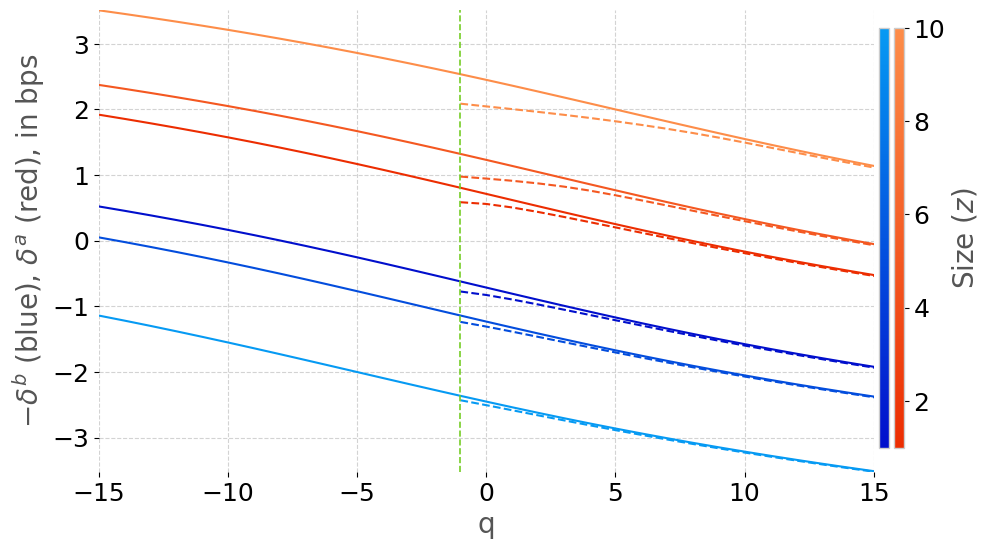

In [ ]:
il.plot_deltas_q(solution, time=0.0)

### How the quotes evolve over the trading period

The function `plot_deltas_time` shows the same half-spreads, now as a function of time for a single size, with each line a different inventory level. The strategy is essentially stationary for most of the horizon and only bends near the terminal time $T$, due to the inventory penalty $\alpha Q_T^2$. Hence using the strategy at $t=0$ (`stationary=True`) is a good approximation.

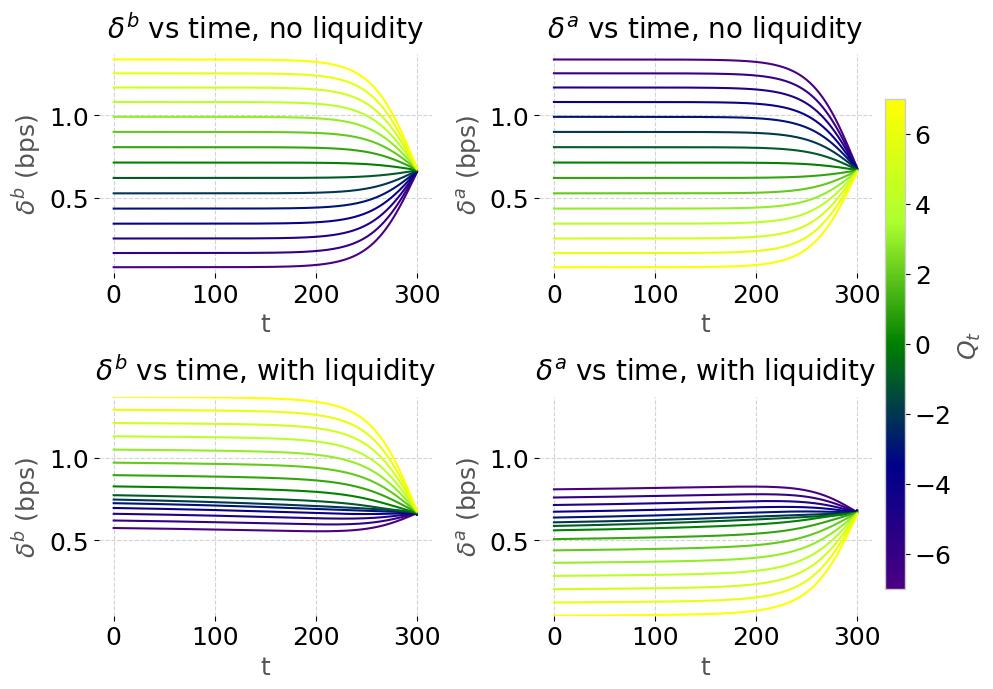

In [ ]:
il.plot_deltas_time(solution, size=1)

### How the strategy responds to the client price

Here we re-solve the model across a range of $\rho$ for two client types and look at two summaries.

The first plot, **`plot_execution_boundary`**, traces the execution boundary — the highest inventory at which the dealer still takes the internal order — against $\rho$. As the order gets more expensive (larger $\rho$) the dealer will only take it when more heavily short, so the boundary falls.

The second plot, **`plot_skew_diff`**, shows the change in quoted spread caused purely by the presence of the internal order ($l=1$ versus $l=0$), across inventory and coloured by $\rho$. This isolates how much the dealer skews its *external* pricing in order to manage risk using the internal exchange.

This cell can take a few moments to run. You can test fewer values of $\rho$ to speed it up.

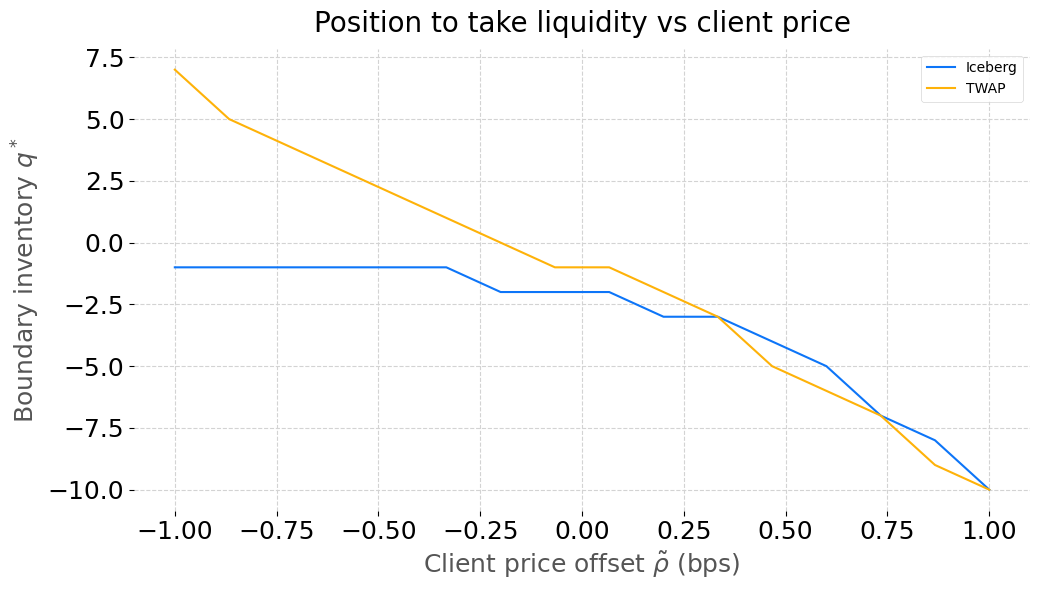

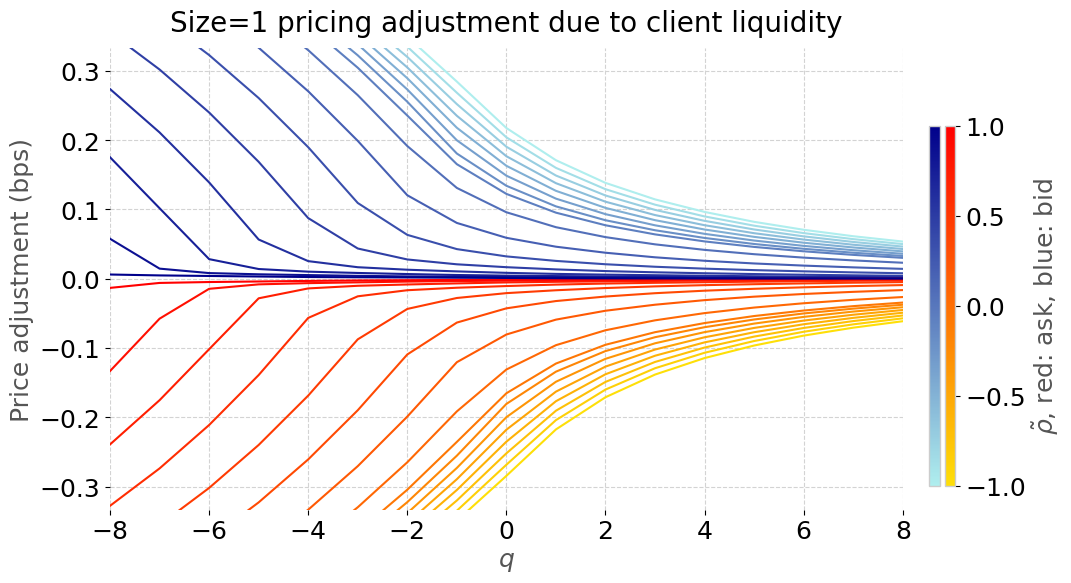

In [ ]:
rhos = np.linspace(-1.0, 1.0, 16)
sols_ice  = [il.solve_hjbqvi(il.iceberg(rho=r), dt=0.02) for r in rhos]
sols_twap = [il.solve_hjbqvi(il.twap(rho=r),    dt=0.02) for r in rhos]

il.plot_execution_boundary(sols_ice,  param_values=list(rhos), param_name='rho', label='Iceberg', solutions_2=sols_twap, label_2='TWAP')

il.plot_skew_diff(sols_ice,  size=1, param_values=list(rhos), param_name='rho')

## Example Simulations

This section runs simulations for a single parameter set and outputs plots describing the simulation.

We compare across three strategies: the optimal strategy found by solving the HJBQVI, a naive benchmark strategy, and a very naive Avellaneda-Stoikov strategy that never trades with the internal exchange.

The naive benchmark strategy reduces to always filling the internal exchange order when short and adjusting pricing when the internal exchange order is present, in a way that represents inserting a compensating order into the externally streamed book. For full details, see the main paper.

### Building the benchmark

Before simulating we construct the **naive benchmark**. It solves the Avellaneda–Stoikov problem (`solve_avellaneda_stoikov`) where a dealer is blind to the internal exchange and then uses a simple rule (`NaivePolicy`): always take the internal order when short, and skew the external ask to reflect the inserted order.

In [ ]:
h_as = il.solve_avellaneda_stoikov(params, dt=0.02)
naive = il.NaivePolicy(params, h_as, iota=0.1)

We now run a vectorised Monte-Carlo simulation of both strategies over many paths. The printed `summary()` reports mean and standard deviation of terminal P&L, the internal volume taken, and how quickly and how often the internal order gets filled.

In [ ]:
PNL_SCALE = 100  # 1 bps x $1m = $100

sim_opt = il.simulate(params, policy, n_paths=5000, dt=0.3, seed=SEED)
sim_nai = il.simulate(params, naive,  n_paths=5000, dt=0.3, seed=SEED)

for label, sim in [('Optimal', sim_opt), ('Naive  ', sim_nai)]:
    s = sim.summary()
    print(f"{label}  PnL ${s['pnl_mean']*PNL_SCALE:7.2f} ± ${s['pnl_std']*PNL_SCALE:.2f}"
          f"  |  internal vol {s['internal_volume_mean']:.2f} units"
          f"  |  first fill {s['first_fill_mean']:.1f}s  ({100*s['fill_fraction']:.1f}% filled)")

Optimal  PnL $3760.01 ± $1568.67  |  internal vol 5.83 units  |  first fill 49.3s  (94.5% filled)
Naive    PnL $3551.31 ± $1656.44  |  internal vol 8.87 units  |  first fill 9.4s  (98.9% filled)


### Terminal P&L distribution

The function `plot_pnl_hist` overlays the distribution of terminal P&L across all paths.

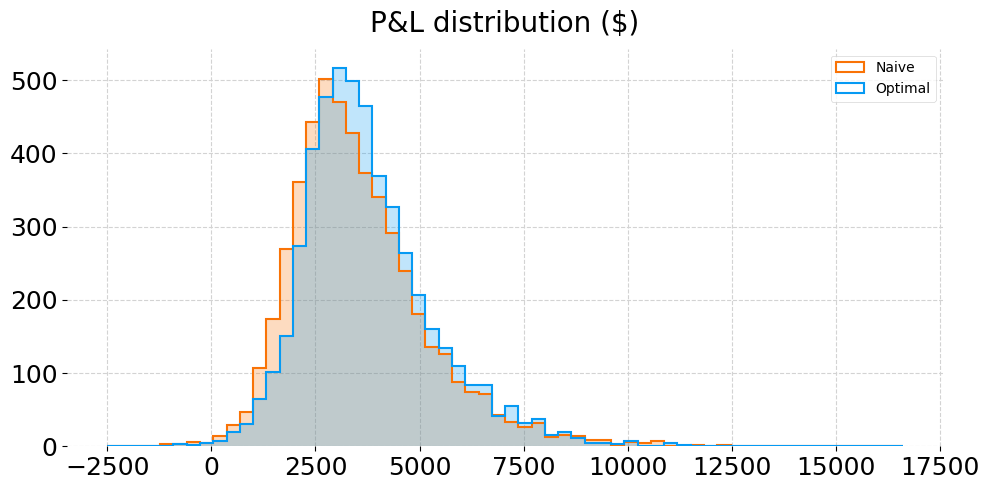

In [ ]:
il.plot_pnl_hist(sim_opt, sim_nai, bins=60, pnl_scale=PNL_SCALE, title='P&L distribution ($)')

### A single simulated path

The function `plot_sample_paths` follows a realisation through time: running P&L, inventory $Q$, and internal-order size $L$, with the optimal strategy on top and the benchmark below. Green dashed lines mark the instants the dealer takes the internal order.

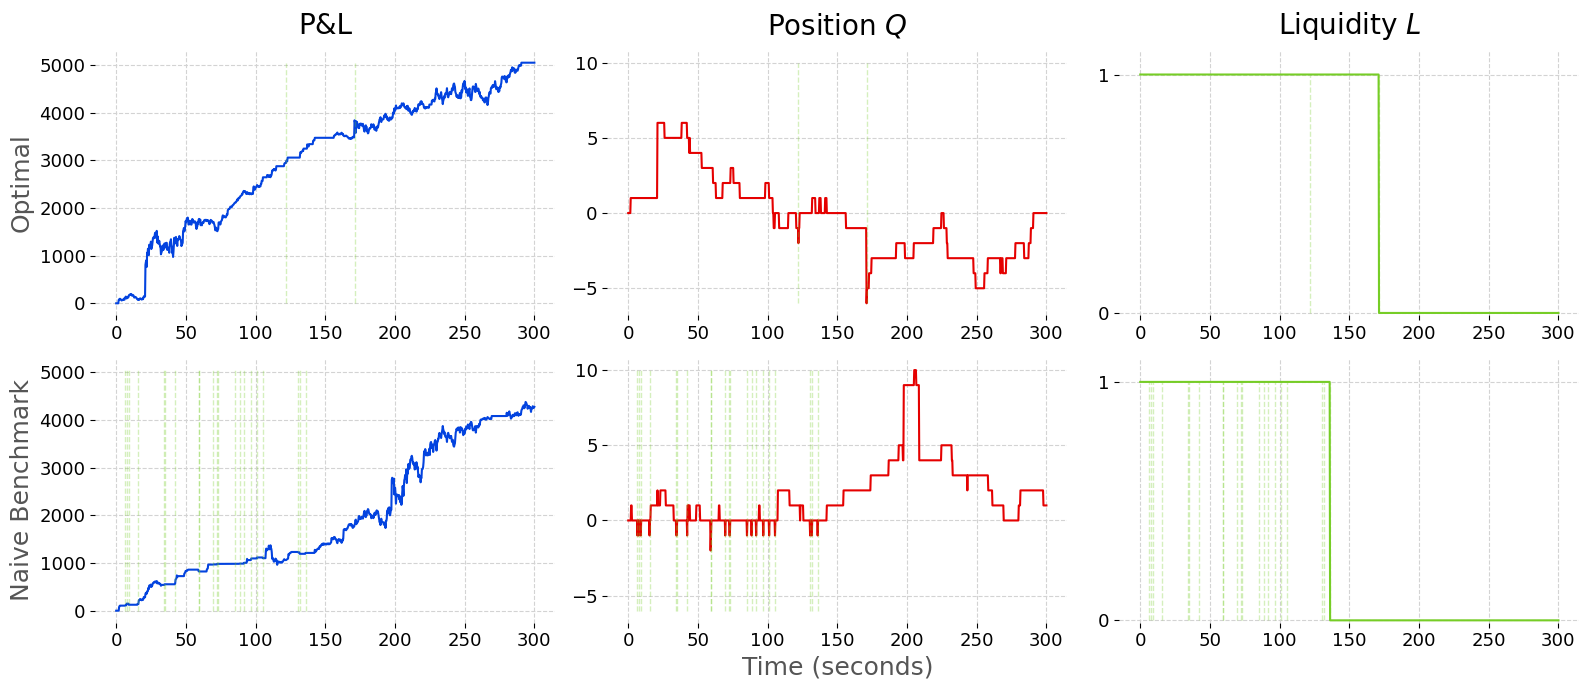

In [ ]:
il.plot_sample_paths(sim_opt, sim_nai, plot_start=0, plot_num=1, pnl_scale=PNL_SCALE)

### The quoted ladder along a path

The function `plot_price_paths` shows the actual prices on one path and includes the mid $S$ together with the full bid/ask ladder (one line per size, lighter for larger sizes), in dollars. The thin green line beneath each panel shows when the internal order is present.

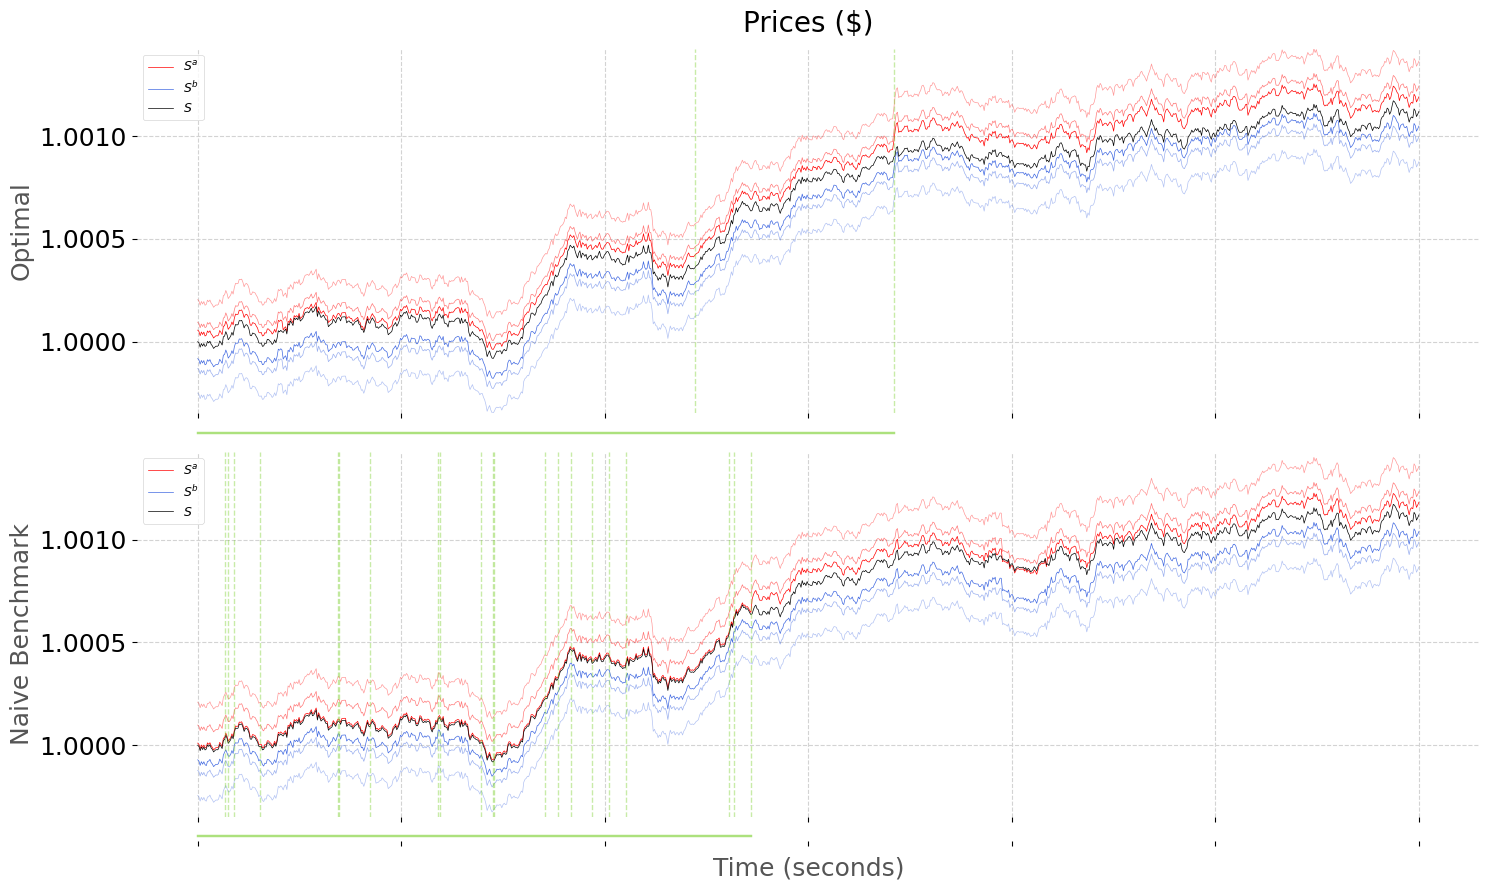

In [ ]:
il.plot_price_paths(sim_opt, sim_nai, policy, naive, path=0)

### Comparison with pure Avellaneda–Stoikov

As a further baseline we simulate a dealer who simply ignores the internal exchange entirely and instead uses standard Avellaneda-Stoikov quotes and never takes the internal order.

Pure AS  PnL $3736.44 ± $1656.82  |  internal vol 0.00 units  |  first fill infs  (0.0% filled)


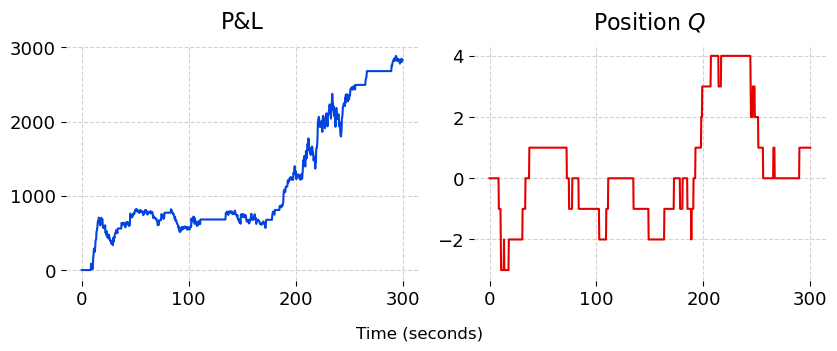

In [ ]:
as_policy = il.ASPolicy(params, h_as)
sim_as = il.simulate(params, as_policy, n_paths=5000, dt=0.3, seed=SEED)

s = sim_as.summary()
print(f"Pure AS  PnL ${s['pnl_mean']*PNL_SCALE:7.2f} ± ${s['pnl_std']*PNL_SCALE:.2f}"
      f"  |  internal vol {s['internal_volume_mean']:.2f} units"
      f"  |  first fill {s['first_fill_mean']:.1f}s  ({100*s['fill_fraction']:.1f}% filled)")

il.plot_sample_paths_2col(sim_as, plot_start=0, plot_num=1, pnl_scale=PNL_SCALE)

## Comparison across clients and price levels

Finally we compare all three client presets at aggressive, mid and passive internal-order prices, reporting mean (std) terminal P&L for both strategies and the average time to first fill.

In [ ]:
presets = {'Iceberg': il.iceberg, 'TWAP': il.twap, 'FullAmt': il.full_amount}
rhos = {'aggressive': -0.2, 'mid': 0.0, 'passive': 0.2}

for name, mk in presets.items():
    for label, rho in rhos.items():
        out = il.solve_and_simulate(mk(rho=rho), n_paths=5000, seed=SEED)
        o, n = out['optimal'].summary(), out['naive'].summary()
        print(f"{name:8s} {label:11s}  "
              f"PnL opt=${o['pnl_mean']*PNL_SCALE:7.2f}(${o['pnl_std']*PNL_SCALE:.2f})  "
              f"nai=${n['pnl_mean']*PNL_SCALE:7.2f}(${n['pnl_std']*PNL_SCALE:.2f})  |  "
              f"first-fill opt={o['first_fill_mean']:6.2f}s  nai={n['first_fill_mean']:5.2f}s")

Iceberg  aggressive   PnL opt=$3859.27($1563.96)  nai=$3569.02($1668.47)  |  first-fill opt= 44.28s  nai= 6.40s
Iceberg  mid          PnL opt=$3760.01($1568.67)  nai=$3551.31($1656.44)  |  first-fill opt= 49.27s  nai= 9.42s
Iceberg  passive      PnL opt=$3702.05($1541.93)  nai=$3476.46($1602.80)  |  first-fill opt= 87.12s  nai=14.78s
TWAP     aggressive   PnL opt=$3932.74($1674.09)  nai=$3496.23($1511.56)  |  first-fill opt=  0.00s  nai= 6.46s
TWAP     mid          PnL opt=$3771.37($1653.13)  nai=$3507.60($1566.89)  |  first-fill opt= 23.74s  nai=10.24s
TWAP     passive      PnL opt=$3656.08($1598.76)  nai=$3496.42($1621.01)  |  first-fill opt= 64.19s  nai=15.85s
FullAmt  aggressive   PnL opt=$3668.24($1970.63)  nai=$3508.10($1618.86)  |  first-fill opt=  0.00s  nai= 6.10s


## Appendix

In this appendix, we describe the HJBQVI used to obtain the optimal solution. Define the value function $v$ as
$$
     v(t, s, q, x, l)
     =  \underset{\delta^{b}, \delta^{a}, \{\tau_{i}\}_{i=1,...}}{\sup}\mathbb{E}\Bigg[X_{T} + Q_{T}S_{T} - \alpha Q^{2}_{T} - \phi\int_{0}^{T}Q^{2}_{t}dt
      - \psi\int_{0}^{T}\max\{L_{t}, 0\}dt\,\bigg\vert\,\mathcal{F}_{t}\Bigg]
$$
The function $h$ is then defined by
$$
 v(t, s, q, x, l) = x + qs + h(t, q, l)
$$
and can be shown to satisfy the HJBQVI
$$
	    0 = \max\Bigg\{
	    \frac{\partial h}{\partial t}(t, q, l) - \phi q^{2} - \psi\max\{l, 0\}
	    +\sum_{z\in\mathcal{Z}}\left(\frac{\lambda^{b, z}e^{-1}}{\kappa^{z}}\exp\left(\kappa^{z}\left( h(t, q+z, l) - h(t, q, l)\right)\right)\right)
	    +\sum_{z\in\mathcal{Z}}\left(\frac{\lambda^{a, z}e^{-1}}{\kappa^{z}}\exp\left(\kappa^{z}\left( h(t, q-z, l) - h(t, q, l) \right)\right)\right)
	    +\nu\left(h(t, q, l-\overline{\ell}) - h(t, q, l)\right)\mathbf{1}_{\{l>0\}} + \mu\left(h(t, q, l+\overline{\ell}) - h(t, q, l)\right)\mathbf{1}_{\{l\leq0\}}, \\
	    \left(h(t, q+1, l-1)\right)\mathbf{1}_{\{l>1\}}
	    +\left(p\,h(t, q+1, l-1+\overline{\ell}) + (1-p)\,h(t, q+1, l-1)\right)\mathbf{1}_{\{l\leq1\}}
	    - h(t, q, l) - \left(\rho\mathbf{1}_{\{l>0\}} + \infty\mathbf{1}_{\{l\leq0\}}\right)
	    \Bigg\}
$$
	with terminal condition $h(T, q, l) = -\alpha q^{2}$.
    
We also have the following result. Let $l=\hat{l}\leq0$ and $\mu=0$ so the client has stopped trading and will not return in the trading period. Then, $h(t, q, \hat{l})=h^{AS}(t, q)$ where $h^{AS}$ is the classical solution to the corresponding (linear-quadratic) Avellaneda-Stoikov model with multiple sizes.
Indeed,
In this case, the HJBQVI simplifies to the ODE
$$
    0 =
    \frac{\partial h}{\partial t}(t, q, \hat{l}) - \phi q^{2}  
    \sum_{z\in\mathcal{Z}}\left(\frac{\lambda^{b, z}e^{-1}}{\kappa^{z}}\exp\left(\kappa^{z}\left( h(t, q+z, \hat{l}) - h(t, q, \hat{l})\right)\right)\right)
    \sum_{z\in\mathcal{Z}}\left(\frac{\lambda^{a, z}e^{-1}}{\kappa^{z}}\exp\left(\kappa^{z}\left( h(t, q-z, \hat{l}) - h(t, q, \hat{l}) \right)\right)\right).
$$
Notice that $\hat{l}$ only appears inside $h$ terms, so we can make the ansatz $h(t, q, \hat{l})=\hat{h}(t, q)$. The resulting ODE is then the one uniquely solved by $\hat{h}(t, q)=h^{AS}(t, q)$.